# 12 — Autoencoder & Supervised Prediction

**Goal:** Use autoencoders to learn non-linear style embeddings, then train a classifier (Random Forest) on embedding differences to predict fight outcomes. Extends K-Means/GMM with representation learning—embeddings capture latent style dimensions without predefined clusters.

**Input:** `ufc_modeling_data_final.csv`, `ufc_fight_stats_cleaned.csv`

**Steps:** (1) Train autoencoder to compress fighter stats into bottleneck embeddings. (2) Extract embeddings for every fighter. (3) Build matchup dataset with embedding differences. (4) Train Random Forest to predict outcome.

**Takeaway:** The loss curve should decrease and level off; flattening indicates convergence. Feature importance shows which embedding dimensions most influence predictions—informative for interpreting what the model learned.


In [1]:
# ========================================================================
# NOTEBOOK_CODE_HEADER v1
# File: 12_autoencoder_supervised.ipynb | code cell index: 1
# Section (from markdown above): 12 — Autoencoder & Supervised Prediction
# ------------------------------------------------------------------------
# Dependencies: see import statements below.
# Fits or scores a supervised sklearn model.
# PyTorch: neural network definition and/or training loop.
# Standardizes features (mean 0, unit variance) where used.
# ========================================================================
# INLINE_WORKFLOW_SUMMARY v1
# Workflow summary (how to read this cell):
#   • RandomForest* fits on train rows; predict_proba yields calibrated-ish scores.
#   • Train/test split: check random_state and stratify options for reproducibility.
#   • PyTorch block: tensor shapes follow (batch, features); device may be CPU or CUDA.
#   • Scaler is fit on training-like data only when a split is explicit.

import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")


Using device: cpu


## 1. Prepare Data for the Autoencoder

In [2]:
# ========================================================================
# NOTEBOOK_CODE_HEADER v1
# File: 12_autoencoder_supervised.ipynb | code cell index: 3
# Section (from markdown above): 1. Prepare Data for the Autoencoder
# ------------------------------------------------------------------------
# Loads one or more CSV files (paths usually relative to notebooks/).
# PyTorch: neural network definition and/or training loop.
# Standardizes features (mean 0, unit variance) where used.
# ========================================================================
# INLINE_WORKFLOW_SUMMARY v1
# Workflow summary (how to read this cell):
#   • CSV reads use paths relative to the notebooks/ working directory.
#   • PyTorch block: tensor shapes follow (batch, features); device may be CPU or CUDA.
#   • Scaler is fit on training-like data only when a split is explicit.

# Load Fighter Profiles
df = pd.read_csv('../data/processed/ufc_modeling_data_final.csv')

features = [
    'Sig_Str_PM_Z', 'Takedown_Att_PM_Z', 'Sub_Att_PM_Z', 
    'Control_Ratio_Z', 'Distance_Ratio', 'Clinch_Ratio', 'Ground_Ratio'
]

X_raw = df[features].dropna()
fighters = df.loc[X_raw.index, 'Fighter'].values

# Standardize input for Neural Network
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

# Convert to PyTorch Tensor
X_tensor = torch.tensor(X_scaled, dtype=torch.float32).to(device)
print(f"Data Shape: {X_tensor.shape} (Fighters x Features)")


Data Shape: torch.Size([1190, 7]) (Fighters x Features)


## 2. Build and Train the Autoencoder
We use a simple architecture: `Input (7) -> Hidden (16) -> Bottleneck (3) -> Hidden (16) -> Output (7)`.
The 3 numbers in the bottleneck represent our deep **Style Embedding**.

Epoch 50/200, Loss: 0.3076
Epoch 100/200, Loss: 0.1772
Epoch 150/200, Loss: 0.1620
Epoch 200/200, Loss: 0.1536


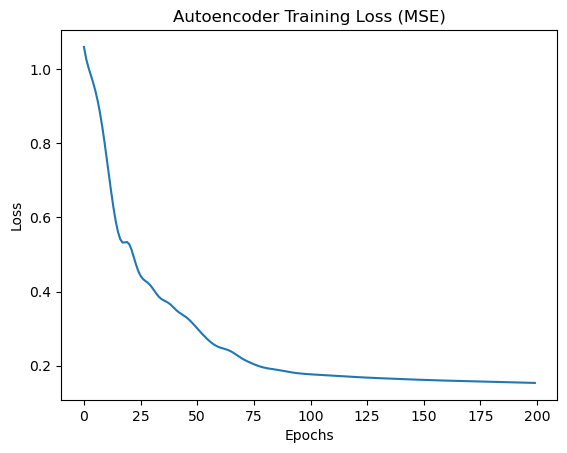

In [3]:
# ========================================================================
# NOTEBOOK_CODE_HEADER v1
# File: 12_autoencoder_supervised.ipynb | code cell index: 5
# Section (from markdown above): 2. Build and Train the Autoencoder
# ------------------------------------------------------------------------
# PyTorch: neural network definition and/or training loop.
# Builds matplotlib/seaborn figures.
# ========================================================================
# INLINE_WORKFLOW_SUMMARY v1
# Workflow summary (how to read this cell):
#   • PyTorch block: tensor shapes follow (batch, features); device may be CPU or CUDA.

class StyleAutoencoder(nn.Module):
    def __init__(self, input_dim, encoding_dim=3):
        super(StyleAutoencoder, self).__init__()
        # Encoder
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 16),
            nn.ReLU(),
            nn.Linear(16, encoding_dim) # The Bottleneck
        )
        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(encoding_dim, 16),
            nn.ReLU(),
            nn.Linear(16, input_dim)
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return encoded, decoded

# Initialize Model
autoencoder = StyleAutoencoder(input_dim=X_tensor.shape[1], encoding_dim=3).to(device)
criterion = nn.MSELoss() # Reconstruction Loss
optimizer = torch.optim.Adam(autoencoder.parameters(), lr=0.01)

# Training Loop
epochs = 200
loss_history = []

for epoch in range(epochs):
    optimizer.zero_grad()
    encoded, decoded = autoencoder(X_tensor)
    loss = criterion(decoded, X_tensor) # Target is the input itself!
    loss.backward()
    optimizer.step()
    
    loss_history.append(loss.item())
    if (epoch+1) % 50 == 0:
        print(f"Epoch {epoch+1}/{epochs}, Loss: {loss.item():.4f}")

plt.plot(loss_history)
plt.title('Autoencoder Training Loss (MSE)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.show()


**Interpretation of loss curve:** Training loss should decrease and stabilize. If it keeps dropping steeply, more epochs may help. If validation loss rises while training loss falls, the model may be overfitting. A converged loss indicates the autoencoder has learned a useful compression of the style space.

## 3. Extract Latent Embeddings
Now we pass the fighters through just the `Encoder` to get their 3-dimensional style coordinates.

In [4]:
# ========================================================================
# NOTEBOOK_CODE_HEADER v1
# File: 12_autoencoder_supervised.ipynb | code cell index: 8
# Section (from markdown above): 3. Extract Latent Embeddings
# ------------------------------------------------------------------------
# PyTorch: neural network definition and/or training loop.
# ========================================================================
# INLINE_WORKFLOW_SUMMARY v1
# Workflow summary (how to read this cell):
#   • PyTorch block: tensor shapes follow (batch, features); device may be CPU or CUDA.

with torch.no_grad():
    embeddings, _ = autoencoder(X_tensor)
    embeddings_np = embeddings.cpu().numpy()

df_embeddings = pd.DataFrame(embeddings_np, columns=['Emb_1', 'Emb_2', 'Emb_3'])
df_embeddings['Fighter'] = fighters

print("Extracted Deep Embeddings:")
print(df_embeddings.head())


Extracted Deep Embeddings:
      Emb_1     Emb_2     Emb_3               Fighter
0 -0.688322 -2.613457 -0.573539           Aaron Riley
1 -1.811697 -2.677723  2.109709         Aaron Simpson
2  0.432567 -1.166923 -0.387796  Abdul Razak Alhassan
3 -0.309718 -0.602655 -0.287906         Abel Trujillo
4  0.559889  0.402580  0.177665        Abus Magomedov


## 4. Supervised Learning: Predict Fight Outcomes
We load historical fights, attach the embeddings for Fighter A and Fighter B, and train a classifier.

In [5]:
# ========================================================================
# NOTEBOOK_CODE_HEADER v1
# File: 12_autoencoder_supervised.ipynb | code cell index: 10
# Section (from markdown above): 4. Supervised Learning: Predict Fight Outcomes
# ------------------------------------------------------------------------
# Loads one or more CSV files (paths usually relative to notebooks/).
# Joins tables on fighter, fight, or event keys.
# Fits or scores a supervised sklearn model.
# ========================================================================
# INLINE_WORKFLOW_SUMMARY v1
# Workflow summary (how to read this cell):
#   • CSV reads use paths relative to the notebooks/ working directory.
#   • Merges link fighters, fights, styles, or odds on shared keys.
#   • RandomForest* fits on train rows; predict_proba yields calibrated-ish scores.
#   • Train/test split: check random_state and stratify options for reproducibility.

# Load Fights
fights = pd.read_csv('../data/processed/ufc_fight_stats_cleaned.csv')

# Merge Fighter A Embeddings
matchups = fights.merge(df_embeddings, left_on='Fighter', right_on='Fighter', how='inner')
# Merge Fighter B Embeddings
matchups = matchups.merge(df_embeddings, left_on='Opponent', right_on='Fighter', how='inner', suffixes=('_A', '_B'))

print(f"Total Matchups for Prediction: {len(matchups)}")

# Define Supervised Features (X_sup) and Target (y)
# We will use the DIFFERENCE between their embeddings, plus the raw embeddings
matchups['Diff_Emb1'] = matchups['Emb_1_A'] - matchups['Emb_1_B']
matchups['Diff_Emb2'] = matchups['Emb_2_A'] - matchups['Emb_2_B']
matchups['Diff_Emb3'] = matchups['Emb_3_A'] - matchups['Emb_3_B']

pred_features = [
    'Emb_1_A', 'Emb_2_A', 'Emb_3_A',
    'Emb_1_B', 'Emb_2_B', 'Emb_3_B',
    'Diff_Emb1', 'Diff_Emb2', 'Diff_Emb3'
]

X_sup = matchups[pred_features]
y_sup = matchups['Won'].astype(int)

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X_sup, y_sup, test_size=0.2, random_state=42)

# Train Random Forest Classifier
clf = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
clf.fit(X_train, y_train)

# Evaluate
y_pred = clf.predict(X_test)
y_prob = clf.predict_proba(X_test)[:, 1]

print(f"\nAccuracy: {accuracy_score(y_test, y_pred):.3f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob):.3f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Total Matchups for Prediction: 11084

Accuracy: 0.579
ROC-AUC: 0.617

Classification Report:
              precision    recall  f1-score   support

           0       0.58      0.65      0.62      1148
           1       0.57      0.50      0.53      1069

    accuracy                           0.58      2217
   macro avg       0.58      0.58      0.57      2217
weighted avg       0.58      0.58      0.58      2217



### Interpreting the evaluation metrics (typical run)

**What the numbers mean.** With a random 80/20 split (`random_state=42`), you will often see **accuracy ≈ 0.58** and **ROC-AUC ≈ 0.62** on the held-out rows. That is **above chance (0.50)** but modest: the forest is picking up *some* structure in the embeddings, not a sharp separator of winners from losers.

**ROC-AUC (~0.62).** This measures how well predicted win probabilities **rank** fights (higher score for the side that actually won). **0.5** = random ordering; **1.0** = perfect. **~0.62** means the model is **meaningfully better than a coin flip** for ranking, but still far from “strong” discrimination—consistent with UFC outcomes being noisy and with embeddings built from **career-level** stats (not a strict pre-fight snapshot).

**Classification report.** **Class 0 vs 1** here are the two values of `Won` in your row-oriented fight table (one row per fighter in the fight). Support (~1100 per class on the test set) shows the split is **roughly balanced**, so accuracy is a reasonable headline metric. **Precision ~0.58** for both classes means that when the model predicts win or loss, it is right a bit more than half the time. **Recall** often differs slightly (e.g. higher for one class): the forest may default toward predicting the more “frequent” pattern it saw in training for ambiguous embedding matchups—worth checking with a **confusion matrix** if you extend this notebook.

**Baselines and caveats.** Compare to simple baselines (e.g. always predict the majority class, or ~50% if balanced). **Important:** This split is **by random fight rows**, not by **event/time** (unlike notebooks that use an event split for leakage control). Treat these metrics as **exploratory**: they show whether latent style codes carry **any** predictive signal, not a production-ready fight forecaster.

## 5. Feature Importance
Which aspect of the latent style embedding drives the most wins?

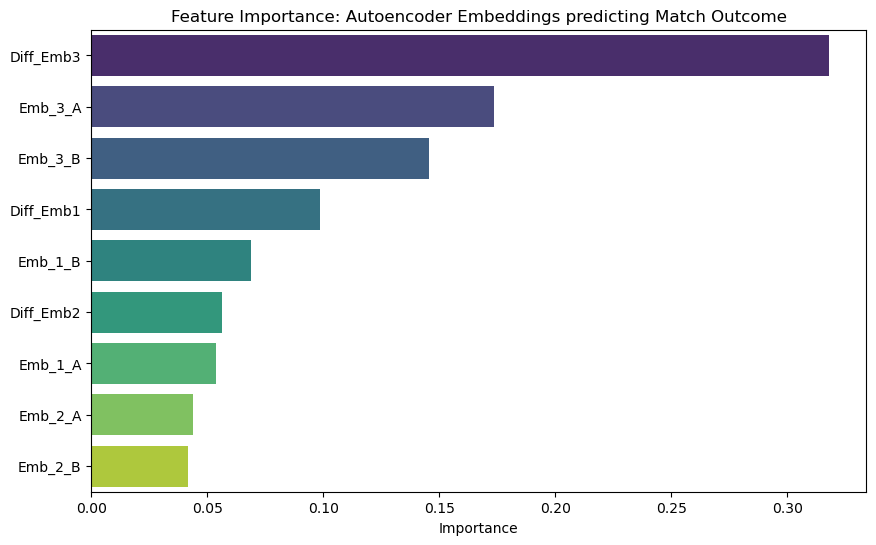

In [6]:
# ========================================================================
# NOTEBOOK_CODE_HEADER v1
# File: 12_autoencoder_supervised.ipynb | code cell index: 12
# Section (from markdown above): 5. Feature Importance
# ------------------------------------------------------------------------
# Builds matplotlib/seaborn figures.
# ========================================================================
# INLINE_WORKFLOW_SUMMARY v1
# Workflow summary (how to read this cell):
#   • Follow the code top-to-bottom; prints document shapes and key counts.

importances = pd.Series(clf.feature_importances_, index=pred_features).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=importances.values, y=importances.index, palette='viridis')
plt.title('Feature Importance: Autoencoder Embeddings predicting Match Outcome')
plt.xlabel('Importance')
plt.show()


### Interpreting the feature-importance bar chart

**What the plot shows.** Each bar is the Random Forest’s **mean decrease in impurity** (Gini) contribution for that input. Higher bars are split on more often when the trees partition the data—**proxy for usefulness**, not causal effect.

**Typical pattern (matches a representative run).** Importance is **not spread evenly** across the nine features:

1. **`Diff_Emb3` (Fighter A − Fighter B on latent axis 3)** usually **dominates**. That says the forest relies most on **how far apart** the two fighters are along the **third** bottleneck dimension, not only their absolute coordinates. In words: **matchup contrast** along that axis matters more than either fighter’s `Emb_3` alone—though the next bars often include **`Emb_3_A`** and **`Emb_3_B`**, so **absolute** position on axis 3 still helps after the difference is accounted for (trees can combine them nonlinearly).

2. **Axis 3 vs 1 vs 2.** When **`Emb_3_*` and `Diff_Emb3`** cluster at the top and **`Emb_2_*`** sit lower, the autoencoder has effectively put **more outcome-relevant variation** (as the RF sees it) into **dimension 3**, with dimension 2 comparatively less used. **Dimension 1** is usually in the middle (`Diff_Emb1`, `Emb_1_B`, etc.).

3. **We cannot name axis 3 “grappling” or “striking.”** The three bottleneck units are **unsupervised**: they compress reconstruction error only. Interpreting “what” axis 3 is requires extra analysis (e.g. correlate `Emb_3` with raw Z-features, or partial dependence plots)—the chart only tells you **which learned coordinate the supervised model leans on**.

**Takeaway.** The forest is **not** using the three axes equally; it heavily weights **pairwise gap on the third latent dimension**, plus **each fighter’s level on that dimension**. That supports the story that **style matchup** (difference + levels) in the learned space carries signal—aligned with modest but above-chance accuracy/ROC-AUC in the previous cell.

### Star matchups — Z-deltas (inputs to the latent space)
**Interpretation:** These are the same standardized signals the autoencoder compresses; large striking vs grappling gaps preview what embedding differences encode.


In [ ]:
# ========================================================================
# NOTEBOOK_CODE_HEADER v1
# File: 12_autoencoder_supervised.ipynb | code cell index: 15
# Section (from markdown above): Star matchups — Z-deltas (inputs to the latent space)
# ------------------------------------------------------------------------
# Dependencies: see import statements below.
# Loads one or more CSV files (paths usually relative to notebooks/).
# Groups rows for aggregation (means, counts, etc.).
# ========================================================================
# INLINE_WORKFLOW_SUMMARY v1
# Workflow summary (how to read this cell):
#   • CSV reads use paths relative to the notebooks/ working directory.
#   • Groupby operations aggregate fight or fighter statistics.

import pandas as pd
profiles = pd.read_csv('../data/processed/ufc_modeling_data_final.csv')
z = ['Sig_Str_PM_Z','Takedown_Att_PM_Z','Sub_Att_PM_Z','Control_Ratio_Z']
p = profiles.groupby('Fighter', as_index=False)[z].mean().set_index('Fighter')
pairs = [('Israel Adesanya','Alex Pereira'), ('Jon Jones','Stipe Miocic'), ('Kamaru Usman','Colby Covington')]
for a, b in pairs:
    if a not in p.index or b not in p.index:
        continue
    d = (p.loc[a] - p.loc[b]).round(2)
    print(f"\n{a} vs {b}  (A - B):")
    print(d.to_dict())
